In [1]:
from CriticalCareUnit import (CCU_model,Scenario,
                                        single_run,
                                        multiple_replications)
import numpy as np
import pandas as pd
import itertools
import math
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import t
sns.set()

In [2]:
# default scenario
args = Scenario()

print('Running multiple replications', end=' => ')
results = multiple_replications(args, n_reps=5)
print('done.\n')
results.mean()

Running multiple replications => done.



CCU_bed_wait_time            31.319023
CCU_queue                     3.783401
bed_util                      0.842273
n_planned_cancellations     226.200000
n_admissions               1335.600000
n_discharges               1313.400000
dtype: float64

#### Estimating warm_up period

In [3]:
# default scenario
args = Scenario()

print('Running multiple replications', end=' => ')
results = multiple_replications(args, n_reps=5)
print('done.\n')
results

Running multiple replications => done.



,CCU_bed_wait_time,CCU_queue,bed_util,n_planned_cancellations,n_admissions,n_discharges
rep,,,,,,
1,19.745764,2.317700,0.840237,242.0,1322.0,1298.0
2,18.171280,2.381413,0.817000,173.0,1345.0,1322.0
3,52.985575,6.964045,0.884686,290.0,1335.0,1315.0
4,20.559077,2.389928,0.828803,199.0,1390.0,1367.0
5,45.133418,4.863919,0.840636,227.0,1286.0,1265.0


In [4]:
from CriticalCareUnit import warmup_analysis
#%%time

# run for 2years (48hrs * 365)
RUN_LENGTH = 48 * 365

# run at least 5 replications, but more might be needed for noisy data
N_REPS = 5

# default scenario
args = Scenario()

#run warm up analysis for scenario
print('Running warm-up analysis with replications. Please wait...', end=' => ')
results = warmup_analysis(args, rc_period=RUN_LENGTH, n_reps=N_REPS)
print('done.')

Running warm-up analysis with replications. Please wait... => done.


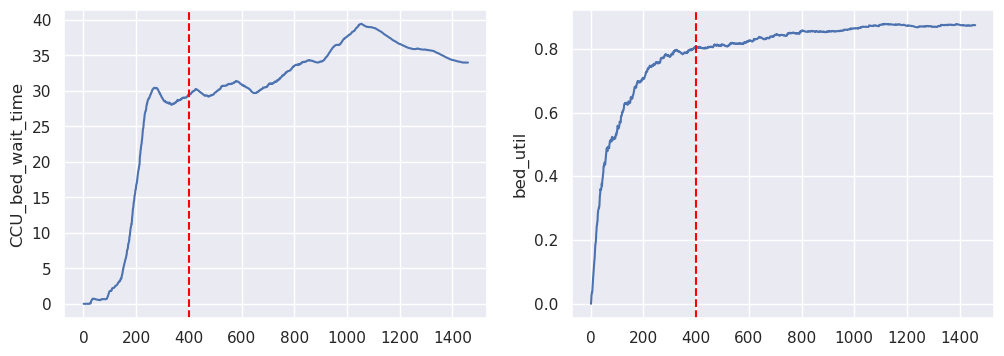

In [8]:
def time_series_inspection(results, warm_up=None):
    '''
    Time series inspection method
    
    Parameters:
    ----------
    results: dict
        The dict of results taken from warmup_analysis
    '''
    
    # create the 4 chart areas to plot
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    
    # take the mean of the columns for each metric and plot
    ax[0].plot(results['CCU_bed_wait_time'].mean(axis=1))
    ax[1].plot(results['bed_util'].mean(axis=1))

    # set the label of each chart
    ax[0].set_ylabel('CCU_bed_wait_time')
    ax[1].set_ylabel('bed_util')

    if warm_up is not None:
        #add warmup cut-off vertical line if one is specified
        ax[0].axvline(x=warm_up, color='red', ls='--')
        ax[1].axvline(x=warm_up, color='red', ls='--')
        
    
    return fig, ax
    
fig, ax = time_series_inspection(results, warm_up=400)

### Re-running model with warm up time

In [9]:
%%time 

############## MODIFICATION  ################################
# set models warmup period
AUDIT_INTERVAL = 12
# set this to the value you selected e.g. between 150 and 250
WARM_UP_INTERVALS = 400
# this converts you warmup interval into minutes.
WARM_UP = WARM_UP_INTERVALS * AUDIT_INTERVAL
##############################################################

# results collection over a single day
RC_PERIOD = 365 * 24

# number of replications
N_REPS = 80

# default scenario
args = Scenario()

# run multiple replications.
print('Running multiple replications', end=' => ')
replications  = multiple_replications(args, rc_period=RC_PERIOD, warm_up=WARM_UP,
                                      n_reps=N_REPS)
print('done.\n')

# show results summary rounded to 2dp
replications.describe().round(2)

Running multiple replications => done.

CPU times: user 172 ms, sys: 4.74 ms, total: 176 ms
Wall time: 1.16 s


,CCU_bed_wait_time,CCU_queue,bed_util,n_planned_cancellations,n_admissions,n_discharges
count,80.00,80.00,80.00,80.00,80.00,80.00
mean,48.05,6.06,0.87,390.15,2031.18,2009.39
std,40.98,5.49,0.02,81.70,69.66,70.03
min,4.85,0.43,0.82,202.00,1879.00,1855.00
25%,21.87,2.58,0.85,321.25,1980.25,1958.50
50%,33.31,4.12,0.87,390.50,2036.50,2013.00
75%,61.09,8.05,0.89,449.50,2085.25,2062.75
max,226.90,30.96,0.93,598.00,2163.00,2139.00


#### Selecting number of replications

In [10]:
def confidence_interval_method(replications, alpha=0.05, desired_precision=0.05, 
                               min_rep=5, decimal_place=2):
    '''
    The confidence interval method for selecting the number of replications
    to run in a simulation.
    
    Finds the smallest number of replications where the width of the confidence
    interval is less than the desired_precision.  
    
    Returns both the number of replications and the full results dataframe.
    
    Parameters:
    ----------
    replications: arraylike
        Array (e.g. np.ndarray or list) of replications of a performance metric
        
    alpha: float, optional (default=0.05)
        procedure constructs a 100(1-alpha) confidence interval for the 
        cumulative mean.
        
    desired_precision: float, optional (default=0.05)
        Desired mean deviation from confidence interval.
        
    min_rep: int, optional (default=5)
        set to a integer > 0 and ignore all of the replications prior to it 
        when selecting the number of replications to run to achieve the desired
        precision.  Useful when the number of replications returned does not
        provide a stable precision below target.
        
    decimal_places: int, optional (default=2)
        sets the number of decimal places of the returned dataframe containing
        the results
    
    Returns:
    --------
        tuple: int, pd.DataFrame
    
    '''
    n = len(replications)
    cumulative_mean = [replications[0]]
    running_var = [0.0]
    for i in range(1, n):
        cumulative_mean.append(cumulative_mean[i-1] + \
                       (replications[i] - cumulative_mean[i-1] ) / (i+1))
        
        # running biased variance
        running_var.append(running_var[i-1] + (replications[i] 
                                               - cumulative_mean[i-1]) \
                            * (replications[i] - cumulative_mean[i]))
        
    # unbiased std dev = running_var / (n - 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        running_std = np.sqrt(running_var / np.arange(n))
    
    # half width of interval
    dof = len(replications) - 1
    t_value = t.ppf(1 - (alpha / 2),  dof)    
    with np.errstate(divide='ignore', invalid='ignore'):
        std_error = running_std / np.sqrt(np.arange(1, n+1))
        
    half_width = t_value * std_error
        
    # upper and lower confidence interval
    upper = cumulative_mean + half_width
    lower = cumulative_mean - half_width
    
    # Mean deviation
    with np.errstate(divide='ignore', invalid='ignore'):
        deviation = (half_width / cumulative_mean) * 100
    
    # commbine results into a single dataframe
    results = pd.DataFrame([replications, cumulative_mean, 
                            running_std, lower, upper, deviation]).T
    results.columns = ['Mean', 'Cumulative Mean', 'Standard Deviation', 
                       'Lower Interval', 'Upper Interval', '% deviation']
    results.index = np.arange(1, n+1)
    results.index.name = 'replications'
    
    # get the smallest no. of reps where deviation is less than precision target
    try:
        n_reps = results.iloc[min_rep:].loc[results['% deviation'] 
                             <= desired_precision*100].iloc[0].name
    except:
        # no replications with desired precision
        message = 'WARNING: the replications do not reach desired precision'
        warnings.warn(message)
        n_reps = -1 

    
    return n_reps, results.round(2)

In [11]:
def plot_confidence_interval_method(reps, conf_ints, metric_name, 
                                    figsize=(12,4)):
    '''
    Plot the confidence intervals and cumulative mean
    
    Parameters:
    ----------
    n_reps: int
        minimum number of reps selected
        
    conf_ints: pandas.DataFrame
       results of the `confidence_interval_method` function
       
    metric_name: str
        Name of the performance measure
        
    figsize: tuple, optional (default=(12,4))
        The size of the plot
        
    Returns:
    -------
        matplotlib.pyplot.axis
    '''
    # plot cumulative mean + lower/upper intervals
    ax = conf_ints[['Cumulative Mean', 'Lower Interval', 
                         'Upper Interval']].plot(figsize=figsize)
    # add the 
    ax.axvline(x=n_reps, ls='--', color='red')
    
    ax.set_ylabel(f'cumulative mean: {metric_name}')
    
    return ax

/tmp/ipykernel_595607/1178184091.py:86: UserWarning: WARNING: the replications do not reach desired precision
  warnings.warn(message)


Analysis of replications for mean CCU wait time...

minimum number of reps for 5% precision: -1



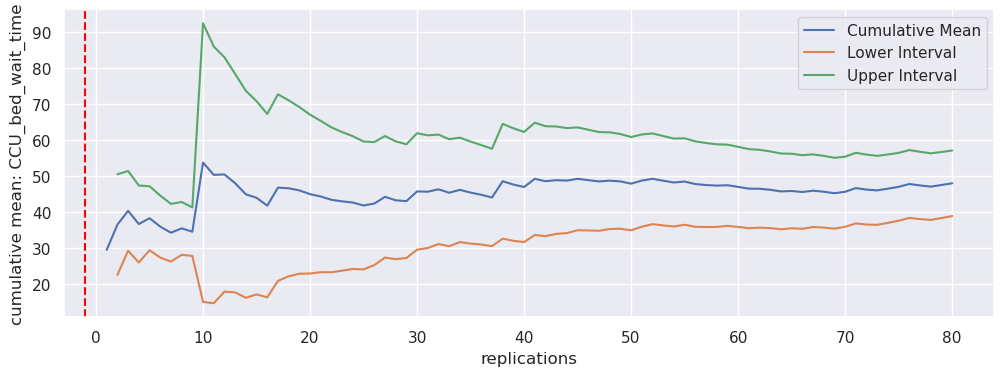

In [12]:
n_reps, conf_ints = \
    confidence_interval_method(replications['CCU_bed_wait_time'].to_numpy(),
                               desired_precision=0.05, min_rep= 50)

print('Analysis of replications for mean CCU wait time...')

#print out the min number of replications to achieve precision
print(f'\nminimum number of reps for 5% precision: {n_reps}\n')

#plot the confidence intervals
ax = plot_confidence_interval_method(n_reps, conf_ints, 
                                     metric_name='CCU_bed_wait_time')

Analysis of replications for operator utilisation...

minimum number of reps for 5% precision: 51



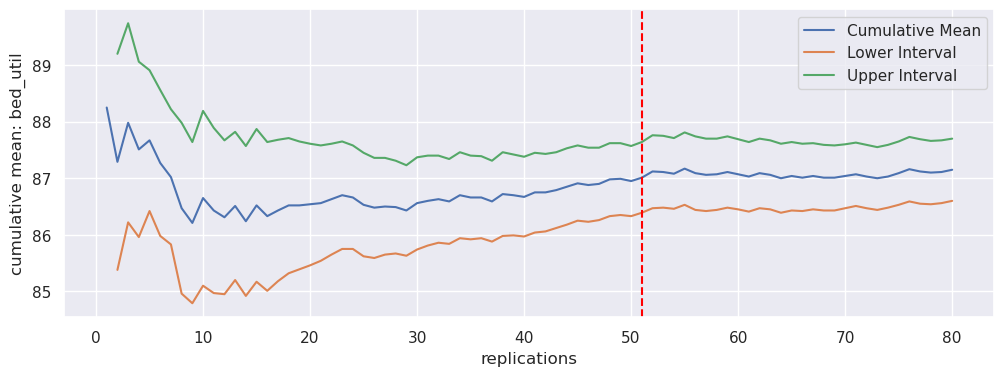

In [13]:
# run the method on the opts util replications
# We already know that we have to run > 50 reps so set min_rep parameter = 50.
n_reps, conf_ints = \
    confidence_interval_method(replications['bed_util'].to_numpy() * 100,
                               desired_precision=0.05, min_rep=50)

print('Analysis of replications for operator utilisation...')

#print out the min number of replications to achieve precision
print(f'\nminimum number of reps for 5% precision: {n_reps}\n')

#plot the confidence intervals
ax = plot_confidence_interval_method(n_reps, conf_ints, 
                                     metric_name='bed_util')

#### Creating scenarios


In [14]:
def get_scenarios():
    '''
    Creates a dictionary object containing
    objects of type `Scenario` to run.
    
    Returns:
    --------
    dict
        Contains the scenarios for the model
    '''
    scenarios = {}
    scenarios['base'] = Scenario()
    
    ########## MODIFICATION HERE ##########################
    scenarios['bed+5'] = Scenario()
    scenarios['bed+5'].CCU_beds += 5

    scenarios['bed+10'] = Scenario()
    scenarios['bed+10'].CCU_beds += 10
    
    scenarios['bed+15'] = Scenario()
    scenarios['bed+15'].CCU_beds += 15

    scenarios['bed+20'] = Scenario()
    scenarios['bed+20'].CCU_beds += 20
    
    #######################################################
    
    return scenarios

In [15]:
def run_scenario_analysis(scenarios, rc_period, warm_up, n_reps):
    '''
    Run each of the scenarios for a specified results
    collection period, warmup and replications.
    
    (note if you have lots of scenarios this may take several minutes)
    '''
    print('Scenario Analysis')
    print(f'No. Scenario: {len(scenarios)}')
    print(f'Replicatins: {n_reps}')
    
    
    scenario_results = {}
    for sc_name, scenario in scenarios.items():
        
        print(f'Running {sc_name}', end=' => ')
        replications  = multiple_replications(scenario, rc_period=RC_PERIOD, 
                                              warm_up=warm_up,
                                              n_reps=n_reps)
        print('done.\n')
        
        #save the results
        scenario_results[sc_name] = replications
    
    print('Scenario analysis complete.')
    return scenario_results

In [20]:
%%time
# script to run model
# note: for 4 scenarios and 50 reps this will take a few minutes.

# set models warmup period
AUDIT_INTERVAL = 12
# set this to the value you selected e.g. between 150 and 250
WARM_UP_INTERVALS = 400 
# this converts you warmup interval into minutes.
WARM_UP = WARM_UP_INTERVALS * AUDIT_INTERVAL

# results collection over a single day
RC_PERIOD = 365 * 24

# number of replications
N_REPS = 51

# get the scenarios
scenarios = get_scenarios()

# run the scenario analysis
scenario_results = run_scenario_analysis(scenarios, RC_PERIOD, WARM_UP,
                                         N_REPS)

Scenario Analysis
No. Scenario: 5
Replicatins: 51
Running base => done.

Running bed+5 => done.

Running bed+10 => done.

Running bed+15 => done.

Running bed+20 => done.

Scenario analysis complete.
CPU times: user 472 ms, sys: 42.6 ms, total: 514 ms
Wall time: 2.18 s


In [21]:
def scenario_summary_frame(scenario_results):
    '''
    Mean results for each performance measure by scenario
    
    Parameters:
    ----------
    scenario_results: dict
        dictionary of replications.  
        Key identifies the performance measure
        
    Returns:
    -------
    pd.DataFrame
    '''
    columns = []
    summary = pd.DataFrame()
    for sc_name, replications in scenario_results.items():
        summary = pd.concat([summary, replications.mean()], axis=1)
        columns.append(sc_name)

    summary.columns = columns
    return summary

summary_frame = scenario_summary_frame(scenario_results)
summary_frame.round(2)

,base,bed+5,bed+10,bed+15,bed+20
CCU_bed_wait_time,48.80,3.56,0.32,0.03,0.00
CCU_queue,6.17,0.41,0.04,0.00,0.00
bed_util,0.87,0.76,0.66,0.58,0.51
n_planned_cancellations,383.35,121.25,21.80,2.37,0.18
n_admissions,2037.39,2309.16,2409.45,2429.10,2431.29
n_discharges,2015.49,2286.22,2385.84,2405.20,2407.63


## visualisations

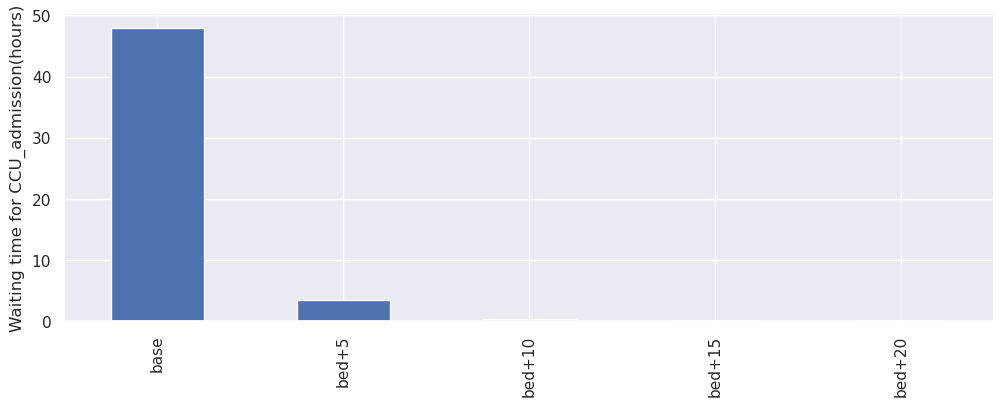

In [18]:
ax = summary_frame.T['CCU_bed_wait_time'].plot.bar(figsize=(12,4))
ax.set_ylabel('Waiting time for CCU_admission(hours)');

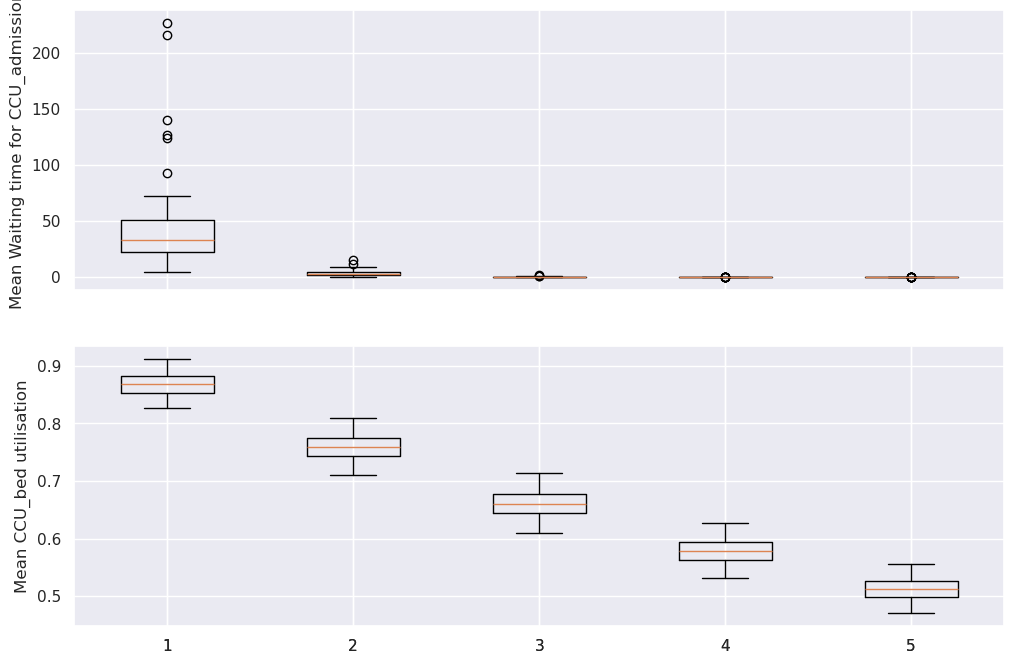

In [19]:
def metric_by_scenario(select, scenario_results):
    metric = pd.DataFrame()
    columns = []
    for sc_name, replications in scenario_results.items():
        metric = pd.concat([metric, replications[select]], 
                           axis=1)
        columns.append(sc_name)

    metric.columns = columns
    return metric


metric_nw = metric_by_scenario('CCU_bed_wait_time', 
                               scenario_results)

metric_nu = metric_by_scenario('bed_util',
                               scenario_results)

fig, ax = plt.subplots(2, 1, figsize=(12,8), 
                       sharex=True)
ax[0].boxplot(metric_nw);
ax[1].boxplot(metric_nu);
ax[0].set_ylabel('Mean Waiting time for CCU_admission')
ax[1].set_ylabel('Mean CCU_bed utilisation');